# PAB-1-Configuration-Chargement-et-Exploration-des-Données

### Configuration et Initialisation de Spark

In [1]:
from pyspark.sql import SparkSession


spark = (
    SparkSession.builder
    .appName("prediction-attrition-bancaire")  
    .master("local[*]")               
    .config("spark.sql.shuffle.partitions", "8")  
    .getOrCreate()
)

print("Spark Version:", spark.version)


Spark Version: 4.0.1


### Chargement des Données

In [16]:
file_path = "../data/dataset-68f599a4c9b84581895311-6907667a3f0be705109390.csv"

df = spark.read.csv(file_path,header=True,inferSchema=True)

df.printSchema()
df.show(5)



root
 |-- RowNumber: integer (nullable = true)
 |-- CustomerId: integer (nullable = true)
 |-- Surname: string (nullable = true)
 |-- CreditScore: integer (nullable = true)
 |-- Geography: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- Balance: double (nullable = true)
 |-- NumOfProducts: integer (nullable = true)
 |-- HasCrCard: integer (nullable = true)
 |-- IsActiveMember: integer (nullable = true)
 |-- EstimatedSalary: double (nullable = true)
 |-- Exited: integer (nullable = true)

+---------+----------+--------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|RowNumber|CustomerId| Surname|CreditScore|Geography|Gender|Age|Tenure|  Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+---------+----------+--------+-----------+---------+------+---+------+---------+-------------+---------+--------------+----

### Statistiques descriptives du DataFrame

In [17]:
df.describe().show()

+-------+------------------+-----------------+-------+-----------------+---------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|summary|         RowNumber|       CustomerId|Surname|      CreditScore|Geography|Gender|               Age|            Tenure|          Balance|     NumOfProducts|          HasCrCard|     IsActiveMember|  EstimatedSalary|             Exited|
+-------+------------------+-----------------+-------+-----------------+---------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|  count|             10000|            10000|  10000|            10000|    10000| 10000|             10000|             10000|            10000|             10000|              10000|              10000|            10000|              10000|
|   mean|            5000.5|

###  Nombre de valeurs nulles par colonne

In [ ]:
from pyspark.sql.functions import col, sum

for i in df.columns:
    null_count = df.filter(df[i].isNull()).count()
    print(f"{i}: {null_count} valeurs nulles")

RowNumber: 0 valeurs nulles
CustomerId: 0 valeurs nulles
Surname: 0 valeurs nulles
CreditScore: 0 valeurs nulles
Geography: 0 valeurs nulles
Gender: 0 valeurs nulles
Age: 0 valeurs nulles
Tenure: 0 valeurs nulles
Balance: 0 valeurs nulles
NumOfProducts: 0 valeurs nulles
HasCrCard: 0 valeurs nulles
IsActiveMember: 0 valeurs nulles
EstimatedSalary: 0 valeurs nulles
Exited: 0 valeurs nulles


### Détection des valeurs aberrantes dans les colonnes numériques à l’aide de l’IQR

In [19]:
from pyspark.sql.functions import col

outlier_counts = {} 
numbers_columns = ["CreditScore","Age","Balance","EstimatedSalary"]


for j in numbers_columns:
    q1,q3 = df.approxQuantile(j,[0.25,0.75],0.01)
    
    IQR = q3 - q1
    
    lower = q1-1.5*IQR
    upper = q3+1.5*IQR

    count_outliers = df.filter((col(j) < lower) | (col(j) > upper)).count()
    outlier_counts[j] = count_outliers
    
for col_name, count in outlier_counts.items():
    print(f"Colonne '{col_name}' : {count} outliers")


Colonne 'CreditScore' : 17 outliers
Colonne 'Age' : 359 outliers
Colonne 'Balance' : 0 outliers
Colonne 'EstimatedSalary' : 0 outliers


### Visualisation des distributions des colonnes numériques avec histogrammes et courbes KDE

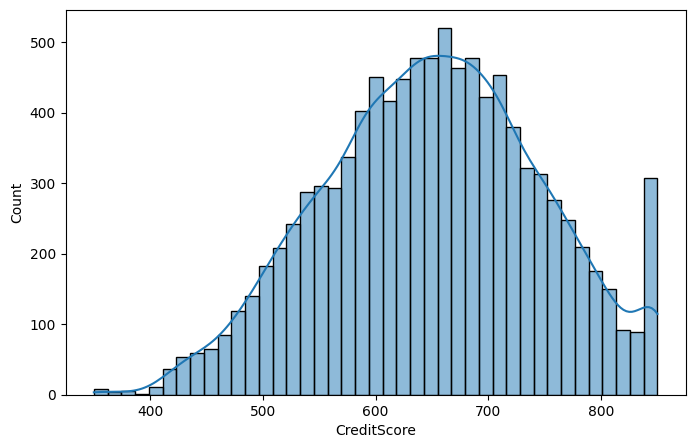

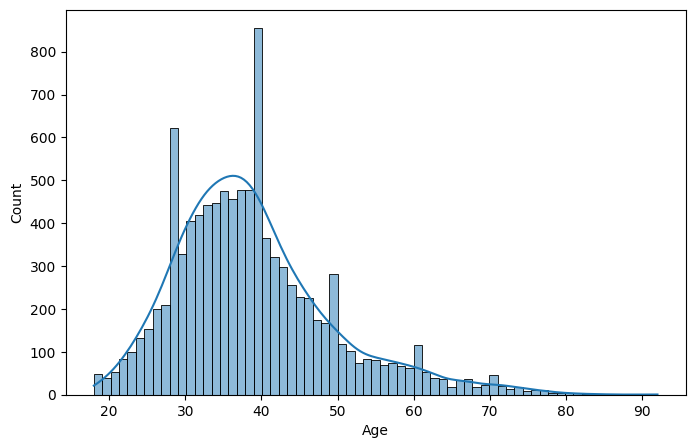

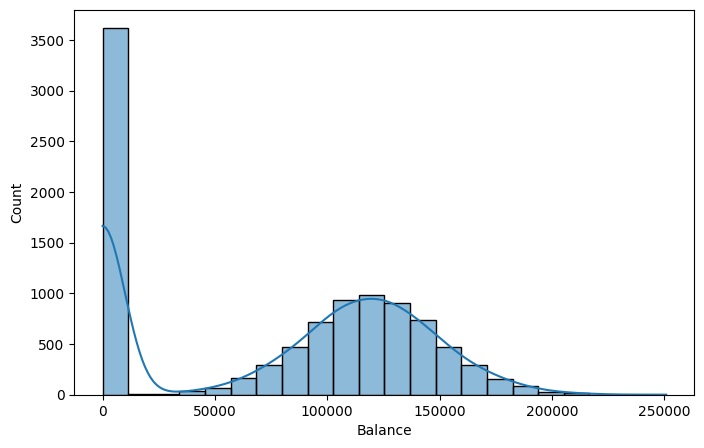

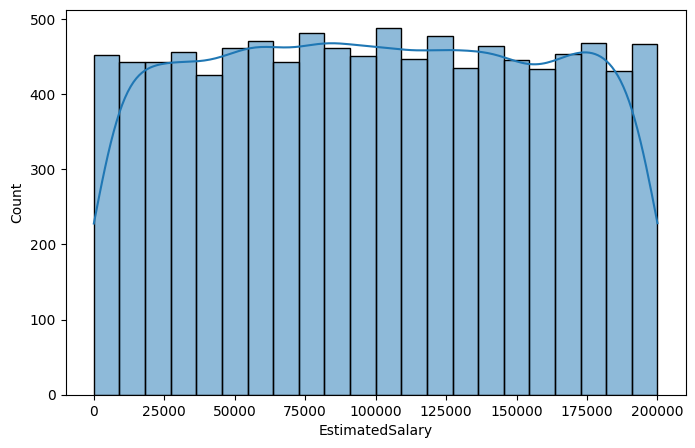

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for i in numbers_columns:
    colonne=df.select(i).toPandas()
    plt.figure(figsize=(8,5))
    sns.histplot(colonne[i],kde=True)

    plt.show()

### Analyse groupée avec groupBy() et agrégations (agg, count, avg, sql, etc.)

In [21]:
df.groupBy("Gender").count().show()

+------+-----+
|Gender|count|
+------+-----+
|Female| 4543|
|  Male| 5457|
+------+-----+



In [22]:
from pyspark.sql.functions import count, avg,sum, max, min

df.groupBy("Gender").agg(count("Balance"),avg("Balance")).show()

+------+--------------+-----------------+
|Gender|count(Balance)|     avg(Balance)|
+------+--------------+-----------------+
|Female|          4543|75659.36913933513|
|  Male|          5457|77173.97450613906|
+------+--------------+-----------------+



In [23]:
df.groupby("IsActiveMember").avg("EstimatedSalary").show()

+--------------+--------------------+
|IsActiveMember|avg(EstimatedSalary)|
+--------------+--------------------+
|             1|   99452.96589400139|
|             0|  100767.20385440304|
+--------------+--------------------+



In [27]:
df.groupBy(["IsActiveMember","Gender"]).agg(count("EstimatedSalary"),avg("EstimatedSalary")).show()



+--------------+------+----------------------+--------------------+
|IsActiveMember|Gender|count(EstimatedSalary)|avg(EstimatedSalary)|
+--------------+------+----------------------+--------------------+
|             1|  Male|                  2867|   99197.86004534362|
|             0|Female|                  2259|  101439.06150066394|
|             0|  Male|                  2590|   100181.2090965252|
|             1|Female|                  2284|   99773.18851576209|
+--------------+------+----------------------+--------------------+



In [30]:
df.groupBy("Gender").agg(
    count("CustomerId").alias("Nombre_clients"),
    avg("Balance").alias("Moyenne_solde"),
    sum("EstimatedSalary").alias("Total_salaires"),
    max("CreditScore").alias("Score_max"),
    min("Age").alias("Age_min")
).explain(True)

== Parsed Logical Plan ==
'Aggregate ['Gender], ['Gender, 'count('CustomerId) AS Nombre_clients#3594, 'avg('Balance) AS Moyenne_solde#3595, 'sum('EstimatedSalary) AS Total_salaires#3596, 'max('CreditScore) AS Score_max#3597, 'min('Age) AS Age_min#3598]
+- Relation [RowNumber#1754,CustomerId#1755,Surname#1756,CreditScore#1757,Geography#1758,Gender#1759,Age#1760,Tenure#1761,Balance#1762,NumOfProducts#1763,HasCrCard#1764,IsActiveMember#1765,EstimatedSalary#1766,Exited#1767] csv

== Analyzed Logical Plan ==
Gender: string, Nombre_clients: bigint, Moyenne_solde: double, Total_salaires: double, Score_max: int, Age_min: int
Aggregate [Gender#1759], [Gender#1759, count(CustomerId#1755) AS Nombre_clients#3594L, avg(Balance#1762) AS Moyenne_solde#3595, sum(EstimatedSalary#1766) AS Total_salaires#3596, max(CreditScore#1757) AS Score_max#3597, min(Age#1760) AS Age_min#3598]
+- Relation [RowNumber#1754,CustomerId#1755,Surname#1756,CreditScore#1757,Geography#1758,Gender#1759,Age#1760,Tenure#1761,Bal

In [ ]:
print(spark.sparkContext.uiWebUrl)

http://DESKTOP-C4SG1SM:4040
